In [1]:
from idlelib.grep import GrepDialog

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from weatherSzegedRegression import y_train

In [2]:
data = pd.read_csv("20-digitalskysurvey.csv")

| Column Name | Description |
|-------------|-------------|
| objid | Object Identifier |
| ra | J2000 Right Ascension (r-band) |
| dec | J2000 Declination (r-band) |
| u | Better of DeV/Exp magnitude fit (u-band) |
| g | Better of DeV/Exp magnitude fit (g-band) |
| r | Better of DeV/Exp magnitude fit (r-band) |
| i | Better of DeV/Exp magnitude fit (i-band) |
| z | Better of DeV/Exp magnitude fit (z-band) |
| run | Run Number |
| rerun | Rerun Number (how the image was processed) |
| camcol | Camera column (1–6, identifies the scanline within the run) |
| field | Field number (a part of the entire image, 2048x1489 pixels) |
| specobjid | Spectroscopic Object Identifier |
| class | Object class (galaxy, star, or quasar) |
| redshift | Final Redshift (wavelength shift toward red end of spectrum) |
| plate | Plate number (unique serial number of spectroscopic plate) |
| mjd | Modified Julian Date of observation |
| fiberid | Fiber ID (identifier for the fiber used in spectrograph) |


In [3]:
data

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.237650e+18,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,1345,301,3,161,5.033450e+17,GALAXY,0.027583,447,51877,246
9996,1.237650e+18,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,1345,301,3,162,5.033400e+17,GALAXY,0.117772,447,51877,228
9997,1.237650e+18,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,1345,301,3,162,8.222620e+18,STAR,-0.000402,7303,57013,622
9998,1.237650e+18,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,1345,301,3,163,5.033400e+17,GALAXY,0.014019,447,51877,229


In [4]:
data.isnull().sum()

objid        0
ra           0
dec          0
u            0
g            0
r            0
i            0
z            0
run          0
rerun        0
camcol       0
field        0
specobjid    0
class        0
redshift     0
plate        0
mjd          0
fiberid      0
dtype: int64

In [5]:
data.describe()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.237650e+18,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,981.034800,301.0,3.648700,302.380100,1.645022e+18,0.143726,1460.986400,52943.533300,353.069400
std,0.000000e+00,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,273.305024,0.0,1.666183,162.577763,2.013998e+18,0.388774,1788.778371,1511.150651,206.298149
min,1.237650e+18,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,308.000000,301.0,1.000000,11.000000,2.995780e+17,-0.004136,266.000000,51578.000000,1.000000
25%,1.237650e+18,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,752.000000,301.0,2.000000,184.000000,3.389248e+17,0.000081,301.000000,51900.000000,186.750000
50%,1.237650e+18,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,756.000000,301.0,4.000000,299.000000,4.966580e+17,0.042591,441.000000,51997.000000,351.000000
75%,1.237650e+18,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,1331.000000,301.0,5.000000,414.000000,2.881300e+18,0.092579,2559.000000,54468.000000,510.000000
max,1.237650e+18,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,1412.000000,301.0,6.000000,768.000000,9.468830e+18,5.353854,8410.000000,57481.000000,1000.000000


In [6]:
colDrop = ["objid", "specobjid", "run", "rerun", "camcol", "field"]

In [7]:
data.drop(colDrop, axis=1, inplace=True)

In [8]:
data.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [10]:
data["class"].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

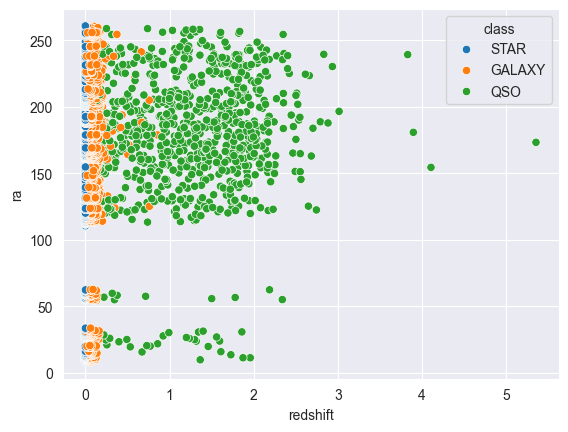

In [11]:
sns.scatterplot(data = data, x="redshift", y="ra", hue="class")
plt.show()

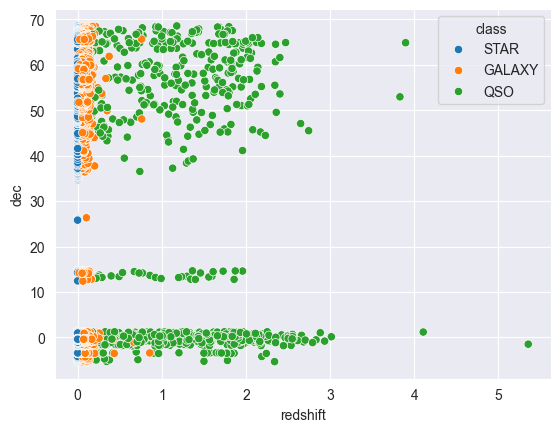

In [12]:
sns.scatterplot(data = data, x="redshift", y="dec", hue="class")
plt.show()

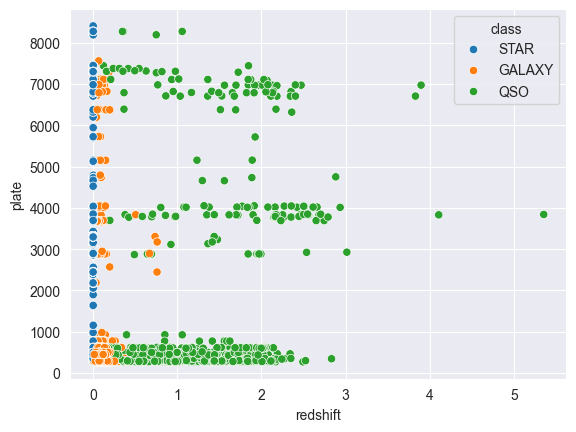

In [13]:
sns.scatterplot(data = data, x="redshift", y="plate", hue="class")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["class"] = le.fit_transform(data["class"])

In [15]:
data.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590,3306,54922,512


In [17]:
data.corr()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.043219,0.030307,-0.095329,-0.086887,0.057485
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,-0.058918,0.067021,0.088342,0.066147,0.155012
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,-0.269044,0.163741,-0.129430,-0.168793,0.011301
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,-0.099212,0.407576,-0.054981,-0.092772,0.047187
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.049628,0.441080,0.019787,-0.009345,0.061081
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.146791,0.431450,0.072958,0.050896,0.069977
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.215758,0.424034,0.112397,0.095658,0.067980
class,-0.043219,-0.058918,-0.269044,-0.099212,0.049628,0.146791,0.215758,1.000000,-0.075510,0.585495,0.648768,0.053593
redshift,0.030307,0.067021,0.163741,0.407576,0.441080,0.431450,0.424034,-0.075510,1.000000,-0.038091,-0.057957,0.046532
plate,-0.095329,0.088342,-0.129430,-0.054981,0.019787,0.072958,0.112397,0.585495,-0.038091,1.000000,0.966881,0.229811


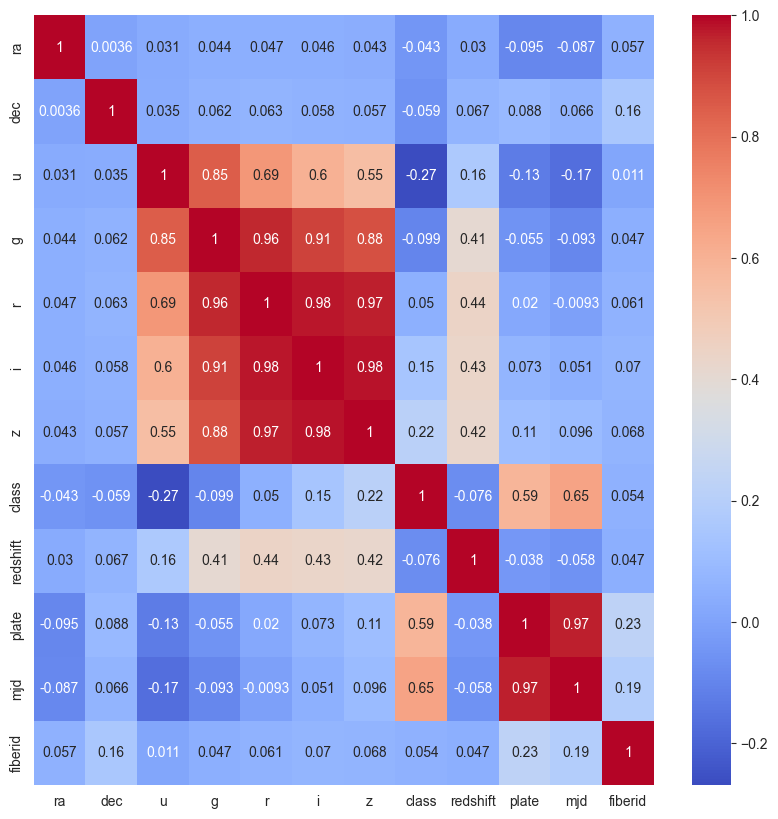

In [19]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

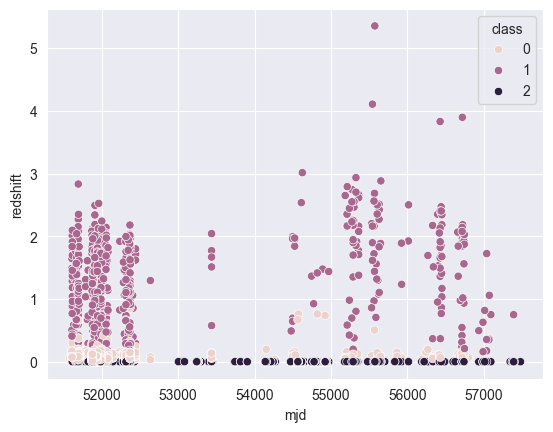

In [20]:
sns.scatterplot(data = data, x="mjd", y="redshift", hue="class")
plt.show()

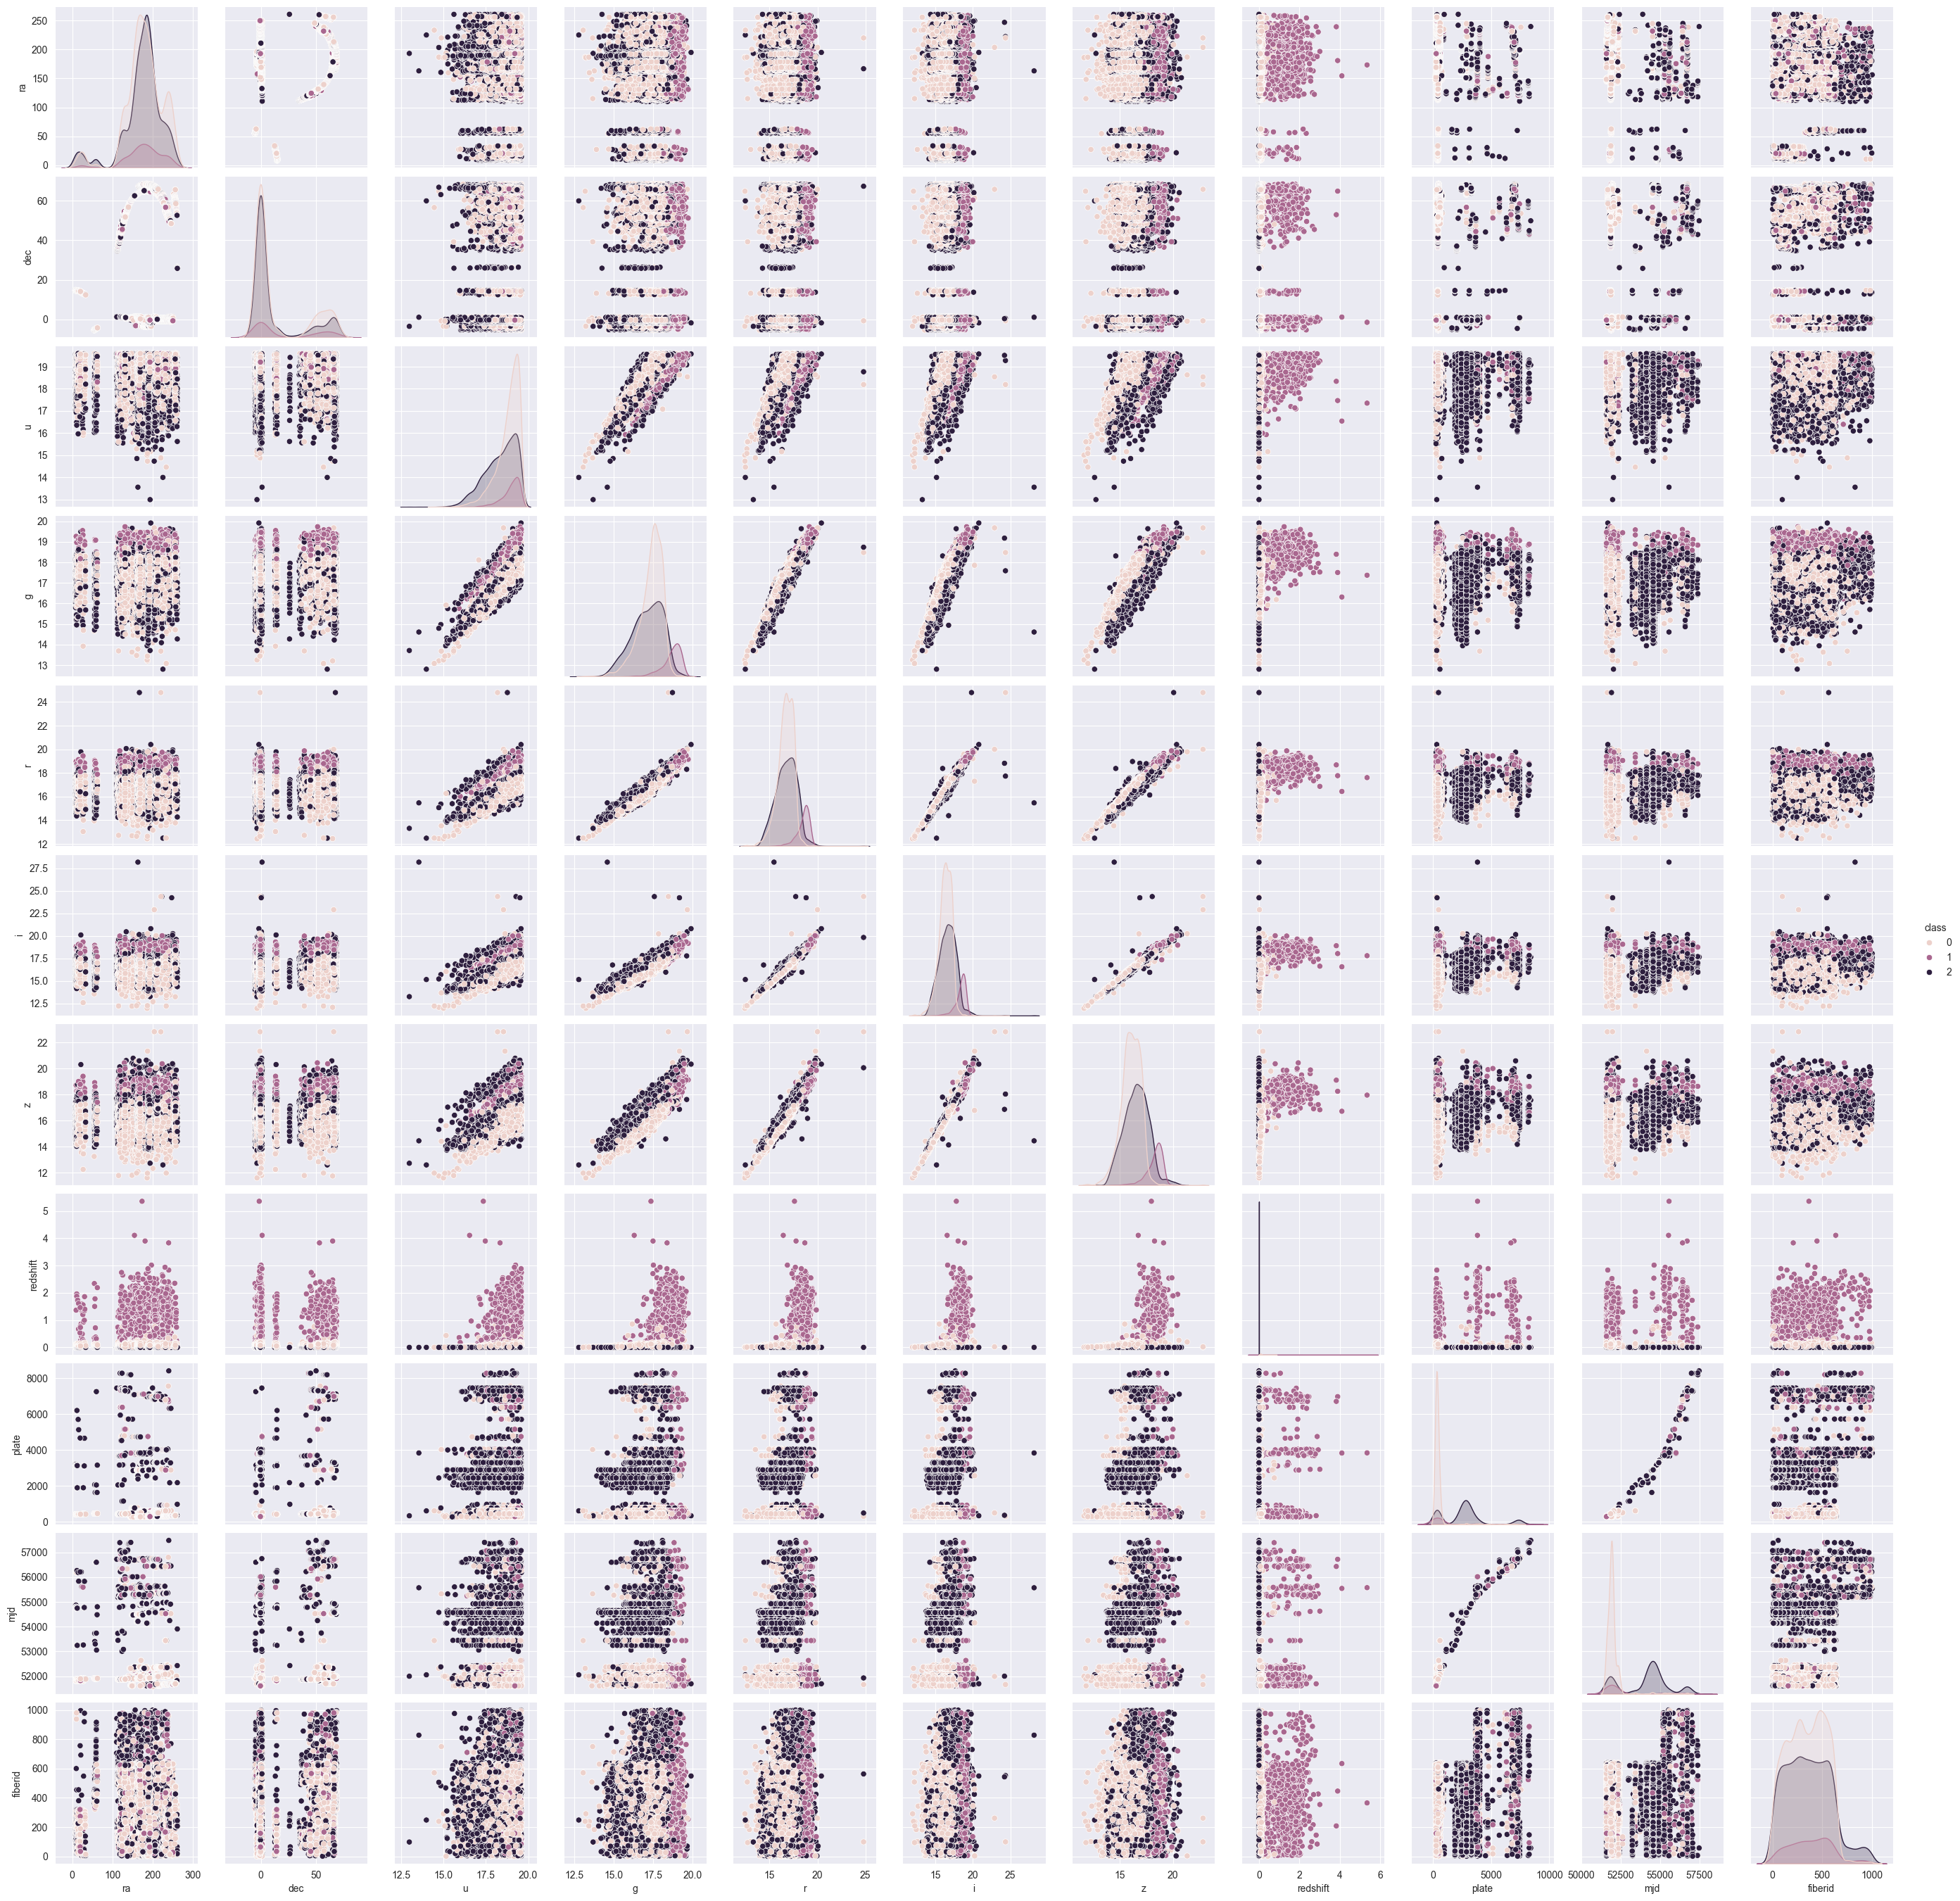

In [21]:
sns.pairplot(data, hue="class")
plt.show()

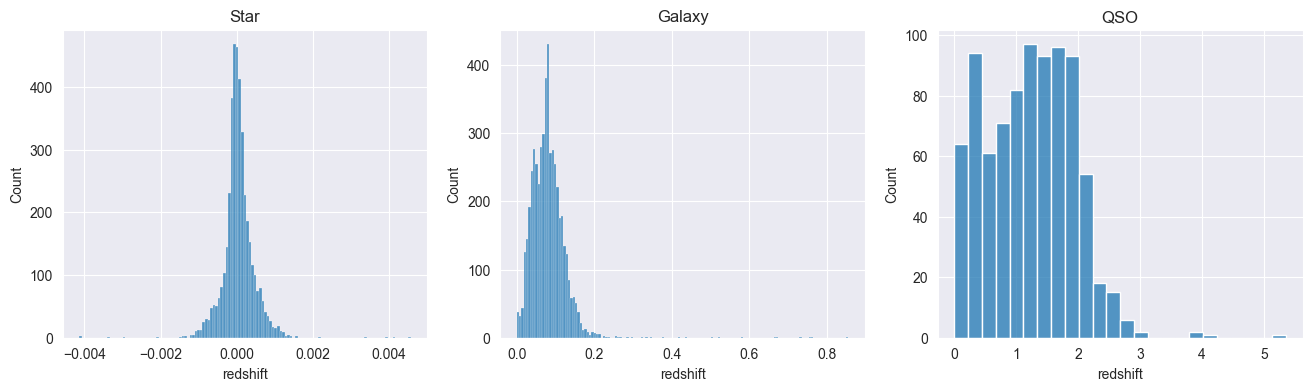

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
ax = sns.histplot(data[data["class"] == 2].redshift, ax=axes[0])
ax.set_title("Star")
ax = sns.histplot(data[data["class"] == 0].redshift, ax=axes[1])
ax.set_title("Galaxy")
ax = sns.histplot(data[data["class"] == 1].redshift, ax=axes[2])
ax.set_title("QSO")
plt.show()

In [27]:
data["class"].value_counts()

class
0    4998
2    4152
1     850
Name: count, dtype: int64

In [30]:
X = data.drop("class", axis=1)
y = data["class"]

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=15)

In [33]:
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# pip install xgboost

In [35]:
from xgboost import XGBClassifier

In [37]:
xgb = XGBClassifier(n_estimators=100)

In [38]:
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9875757575757576
Confusion matrix:
 [[1667   13    7]
 [  17  253    1]
 [   3    0 1339]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.95      0.93      0.94       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.97      0.98      3300
weighted avg       0.99      0.99      0.99      3300



In [42]:
# hyperparameter tuning
# https://xgboost.readthedocs.io/en/stable/parameter.html

params = {
    "n_estimators": [100, 150, 200, 500],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5, 7, 20, 15, 30],
    "colsample_bytree": [0.2, 0.3, 0.4, 0.8, 1],
}

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
grid = GridSearchCV(estimator=XGBClassifier(), param_grid=params, cv=5, n_jobs=-1)

In [45]:
grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.2, 0.3, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [46]:
grid.best_params_

{'colsample_bytree': 0.3,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 500}

In [47]:
y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9884848484848485
Confusion matrix:
 [[1669   11    7]
 [  18  252    1]
 [   1    0 1341]]
Classification report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.96      0.93      0.94       271
           2       0.99      1.00      1.00      1342

    accuracy                           0.99      3300
   macro avg       0.98      0.97      0.98      3300
weighted avg       0.99      0.99      0.99      3300

